In [1]:
%pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Refactor: Separate Generation Process for Bus Train and other Landmarks. Remove unused Bus/Train stations at end or replace them with others.

In [3]:
import csv
import random
import os
import math
import matplotlib.pyplot as plt

In [4]:
#Landmark Generation Parameters
names = ["Apple", "Banana", "Cat", "Dog", "Egg", "Fruit", "Grape", "Happy"]
types = ["Residential Building", "Shopping Mall", "Recreation Park", "Bus Station", "Train Station"]
abb = ["RB", "SM", "RP", "BS", "TS"]
lat_range = [22.08, 22.35]
long_range = [113.49, 114.31]

#Bus Line Generation Parameters
bus_min_num_stops = 5
bus_max_num_stops = 10
bus_cost = 25

#Train Line Generation Parameters
train_min_num_stops = 7
train_max_num_stops = 15
train_cost = 50

#Filepaths
output_path_name = "../Data/TestCaseMap"
landmark_output_path = f"{output_path_name}_Landmarks.csv"
bus_lines_output_path = f"{output_path_name}_BusLines.csv"
train_lines_output_path = f"{output_path_name}_TrainLines.csv"
train_fees_output_path = f"{output_path_name}_TrainFees.csv"
plot_output_path = f"{output_path_name}_TransportNetwork.png"

# Generation Quantities
num_of_landmarks = 500
num_of_bus_lines = 15
num_of_train_lines = 10


In [5]:
def calculate_distance(lat1, lon1, lat2, lon2):
    return math.hypot(lat2 - lat1, lon2 - lon1)

In [6]:
def create_random_list_of_landmarks(num_of_landmarks: int, output_path: str = "../Data/DefaultLandmark.csv"):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    name_counts = {name: 0 for name in names}
    landmarks = []
    headers = ["Landmark_Name", "Type", "Abbreviation", "Latitude", "Longitude"]

    #Randomly create new landmarks and add them to list of landmarks
    for new_landmark in range(num_of_landmarks):

        base_name = random.choice(names)
        name_counts[base_name] += 1
        current_index = name_counts[base_name]
        
        type_index = random.randint(0, len(types) - 1)
        landmark_type = types[type_index]
        landmark_abb = abb[type_index]
        full_name = f"{base_name} {current_index} {landmark_type}"
        
        lat = round(random.uniform(lat_range[0], lat_range[1]), 6)
        lon = round(random.uniform(long_range[0], long_range[1]), 6)
        landmarks.append([full_name, landmark_type, landmark_abb, lat, lon])
        
    #Output as CSV    
    with open(output_path, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(headers)
        writer.writerows(landmarks)
    print(f"Landmarks saved to {output_path}")
    return landmarks 

In [7]:
def create_random_list_of_bus_lines(list_of_landmarks, max_number_of_bus_lines_to_create: int, output_path: str = "../Data/DefaultBusLines.csv"):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    bus_stations = [bs for bs in list_of_landmarks if bs[1] == "Bus Station"]
    if len(bus_stations) < 4:
        print("Not enough bus stations generated to create a bus line.")
        return
    used_endpoints = set()
    bus_lines = []

    #Generate Bus Lines
    for line_id in range(1, max_number_of_bus_lines_to_create + 1):
        num_stops = random.randint(bus_min_num_stops, min(bus_max_num_stops, len(bus_stations)))        
        
        available_endpoints = [bs for bs in bus_stations if bs[0] not in used_endpoints]
        if len(available_endpoints) < 2:
            print("No more unique endpoints. Stopping bus line generation.")
            break            

        #Select Starting Stations and Ending Stations
        start_point, end_point = random.sample(available_endpoints, 2)
        used_endpoints.add(start_point[0])
        used_endpoints.add(end_point[0])

        #Criteria for selecting intermediate stations
        max_dist = calculate_distance(start_point[3], start_point[4], end_point[3], end_point[4])
        
        intermediate_candidates = []
        for bs in bus_stations:
            if bs[0] == start_point[0] or bs[0] == end_point[0]:
                continue
            dist_to_start = calculate_distance(start_point[3], start_point[4], bs[3], bs[4])
            dist_to_end = calculate_distance(end_point[3], end_point[4], bs[3], bs[4])
            if dist_to_start <= max_dist and dist_to_end <= max_dist:
                intermediate_candidates.append(bs)
                
        num_intermediate_needed = num_stops - 2
        
        if len(intermediate_candidates) < num_intermediate_needed:
            selected_intermediates = intermediate_candidates
        else:
            selected_intermediates = random.sample(intermediate_candidates, num_intermediate_needed)
        
        #Final Path Generation    
        start_lat, start_lon = start_point[3], start_point[4]
        def distance_from_start(station):
            station_lat, station_lon = station[3], station[4]
            return calculate_distance(start_lat, start_lon, station_lat, station_lon)
        selected_intermediates.sort(key=distance_from_start)
        final_line = [start_point] + selected_intermediates + [end_point]

        
        line_price = round(max_dist * bus_cost, 1)
        for order, station in enumerate(final_line, start=1):
            bus_lines.append([f"BusLine_{line_id}", order, station[0], line_price])

    #Output as CSV   
    headers = ["Line_ID", "Stop_Order", "Station_Name", "Price"]
    with open(output_path, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(headers)
        writer.writerows(bus_lines)
    print(f"Bus lines saved to {output_path}")

In [8]:
def create_random_list_of_train_lines(list_of_landmarks, max_number_of_train_lines_to_create: int, lines_output_path: str = "../Data/DefaultTrainLines.csv", fees_output_path: str = "../Data/DefaultTrainFees.csv"):
    os.makedirs(os.path.dirname(lines_output_path), exist_ok=True)
    os.makedirs(os.path.dirname(fees_output_path), exist_ok=True)
    
    train_stations = [ts for ts in list_of_landmarks if ts[1] == "Train Station"]
    if len(train_stations) < 4:
        print("Not enough train stations generated to create a train line.")
        return
        
    used_endpoints = set()
    train_lines = []
    train_fees = []

    #Generate Train Lines
    for line_id in range(1, max_number_of_train_lines_to_create + 1):
        num_stops = random.randint(train_min_num_stops, min(train_max_num_stops, len(train_stations)))        
        
        available_endpoints = [ts for ts in train_stations if ts[0] not in used_endpoints]
        if len(available_endpoints) < 2:
            print("No more unique endpoints. Stopping train line generation.")
            break            

        #Select Starting Stations and Ending Stations
        start_point, end_point = random.sample(available_endpoints, 2)
        used_endpoints.add(start_point[0])
        used_endpoints.add(end_point[0])

        #Criteria for selecting intermediate stations
        max_dist = calculate_distance(start_point[3], start_point[4], end_point[3], end_point[4])
        
        intermediate_candidates = []
        for ts in train_stations:
            if ts[0] == start_point[0] or ts[0] == end_point[0]:
                continue
            dist_to_start = calculate_distance(start_point[3], start_point[4], ts[3], ts[4])
            dist_to_end = calculate_distance(end_point[3], end_point[4], ts[3], ts[4])
            if dist_to_start <= max_dist and dist_to_end <= max_dist:
                intermediate_candidates.append(ts)
                
        num_intermediate_needed = num_stops - 2
        
        if len(intermediate_candidates) < num_intermediate_needed:
            selected_intermediates = intermediate_candidates
        else:
            selected_intermediates = random.sample(intermediate_candidates, num_intermediate_needed)
        
        #Final Path Generation    
        start_lat, start_lon = start_point[3], start_point[4]
        def distance_from_start(station):
            station_lat, station_lon = station[3], station[4]
            return calculate_distance(start_lat, start_lon, station_lat, station_lon)
            
        selected_intermediates.sort(key=distance_from_start)
        final_line = [start_point] + selected_intermediates + [end_point]

        for order, station in enumerate(final_line, start=1):
            train_lines.append([f"TrainLine_{line_id}", order, station[0]])
            
        # Calculate Train Fees
        for i in range(len(final_line) - 1):
            station_a = final_line[i]
            station_b = final_line[i+1]
            
            leg_distance = calculate_distance(station_a[3], station_a[4], station_b[3], station_b[4])
            leg_price = round(leg_distance * train_cost, 2)
            
            train_fees.append([f"TrainLine_{line_id}", station_a[0], station_b[0], leg_price])

    # Output Train Lines as CSV   
    lines_headers = ["Line_ID", "Stop_Order", "Station_Name"]
    with open(lines_output_path, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(lines_headers)
        writer.writerows(train_lines)
    print(f"Train lines saved to {lines_output_path}")
    
    # Output Train Fees as CSV
    fees_headers = ["Line_ID", "From_Station", "To_Station", "Price"]
    with open(fees_output_path, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(fees_headers)
        writer.writerows(train_fees)
    print(f"Train fees saved to {fees_output_path}")

In [9]:
def visualize_transport_network(list_of_landmarks, bus_lines_path="../Data/DefaultBusLines.csv", train_lines_path="../Data/DefaultTrainLines.csv"):
    plt.figure(figsize=(12, 8))    
    landmark_coords = {lm[0]: (lm[3], lm[4]) for lm in list_of_landmarks}
    
    #Plot Landmarks
    colors = {
        "Residential Building": "gray",
        "Shopping Mall": "blue",
        "Recreation Park": "green",
        "Bus Station": "orange",
        "Train Station": "red"
    }
    markers = {
        "Residential Building": ".",
        "Shopping Mall": "s",
        "Recreation Park": "^",
        "Bus Station": "o",
        "Train Station": "D"
    }
    
    for lm in list_of_landmarks:
        name, lm_type, lat, lon = lm[0], lm[1], lm[3], lm[4]
        plt.scatter(lon, lat, c=colors.get(lm_type, "black"), 
                    marker=markers.get(lm_type, "o"), label=lm_type, alpha=0.6, zorder=2)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title="Landmark Types", loc="upper right")

    #Plot Bus Lines
    if os.path.exists(bus_lines_path):
        with open(bus_lines_path, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            bus_lines = {}
            for row in reader:
                line_id = row["Line_ID"]
                if line_id not in bus_lines:
                    bus_lines[line_id] = []
                bus_lines[line_id].append(row["Station_Name"])
                
        for line_id, stations in bus_lines.items():
            lats = [landmark_coords[s][0] for s in stations if s in landmark_coords]
            lons = [landmark_coords[s][1] for s in stations if s in landmark_coords]
            plt.plot(lons, lats, color='orange', linestyle='--', linewidth=2, alpha=0.7, zorder=1)
    else:
        print(f"Warning: {bus_lines_path} not found.")

    #Plot Train Lines
    if os.path.exists(train_lines_path):
        with open(train_lines_path, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            train_lines = {}
            for row in reader:
                line_id = row["Line_ID"]
                if line_id not in train_lines:
                    train_lines[line_id] = []
                train_lines[line_id].append(row["Station_Name"])
                
        for line_id, stations in train_lines.items():
            lats = [landmark_coords[s][0] for s in stations if s in landmark_coords]
            lons = [landmark_coords[s][1] for s in stations if s in landmark_coords]
            plt.plot(lons, lats, color='red', linestyle='-', linewidth=3, alpha=0.7, zorder=1)
    else:
        print(f"Warning: {train_lines_path} not found.")

    plt.title("Geographic Visualization of Landmarks, Bus Lines, and Train Lines")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [10]:
landmarks = create_random_list_of_landmarks(num_of_landmarks, landmark_output_path)
create_random_list_of_bus_lines(landmarks, num_of_bus_lines, bus_lines_output_path)
create_random_list_of_train_lines(landmarks, num_of_train_lines, train_lines_output_path, train_fees_output_path)

Landmarks saved to ../Data/TestCaseMap_Landmarks.csv
Bus lines saved to ../Data/TestCaseMap_BusLines.csv
Train lines saved to ../Data/TestCaseMap_TrainLines.csv
Train fees saved to ../Data/TestCaseMap_TrainFees.csv


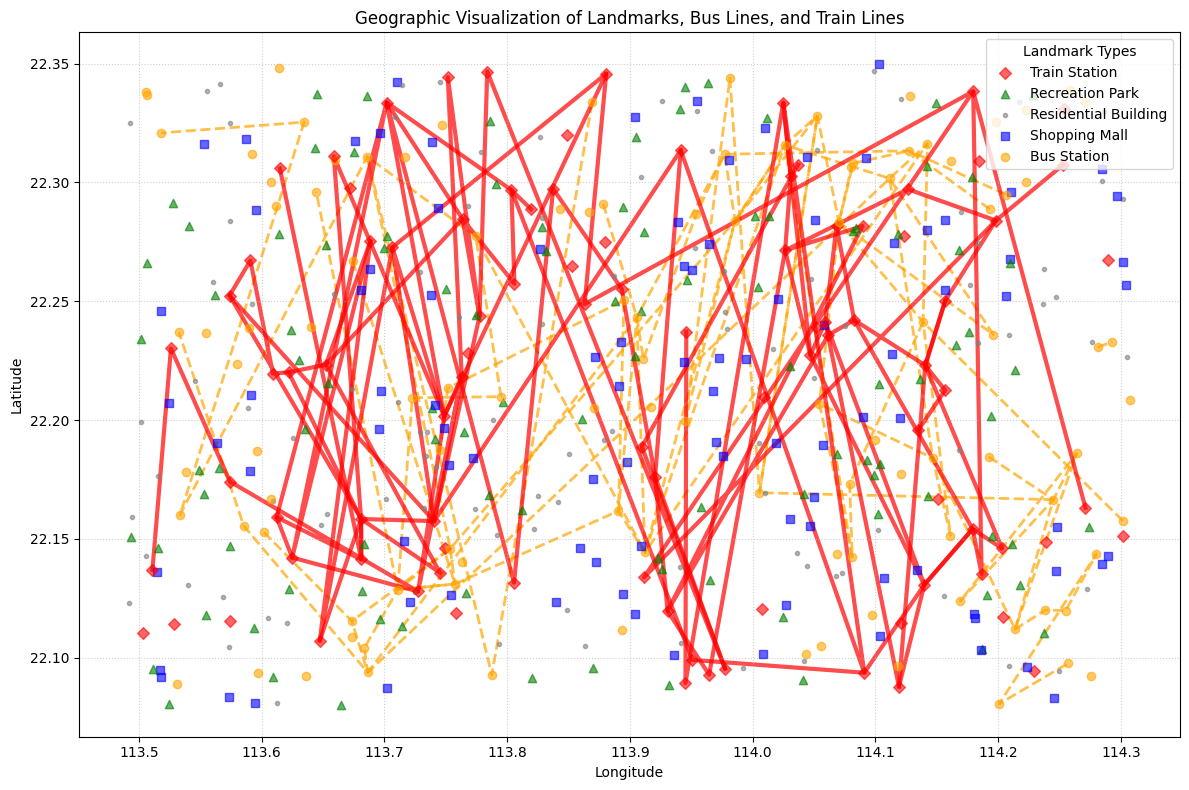

In [11]:
#Please Install Matplot lib before using this function.
visualize_transport_network(landmarks, bus_lines_output_path, train_lines_output_path)